In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("mental_health_combined_test.csv")
df

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety
...,...,...
987,Someone jumped off my building todayI wonder w...,Suicidal
988,helpp??? took 2800mg ibuprofen &amp; 1800mg as...,Suicidal
989,I flunked all my exams am gonna suicideAm goin...,Suicidal
990,I've Got A Serious ProblemI am considering tak...,Suicidal


In [4]:
#Data inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    992 non-null    object
 1   status  992 non-null    object
dtypes: object(2)
memory usage: 15.6+ KB


In [5]:
df.describe()

,text,status
count,992,992
unique,992,4
top,Pictures at the mallI’ve realized that I want ...,Anxiety
freq,1,248


In [6]:
#Check for null values
print(df.isnull().sum())

text      0
status    0
dtype: int64


In [7]:
#Check for value counts
a=['text','status']
for i in a:
    print("Column : ",i)
    print(df[i].value_counts())
    print("------------------------------")

Column :  text
text
Pictures at the mallI’ve realized that I want to take some portraits at the mall for the purpose of an obituary. A nice headshot that looks like me, so my loved ones won’t have to search for one. I’m 32 and I’ve had more and more progressively vivid and harmful thoughts. They won’t abate, and I just want to prepare.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

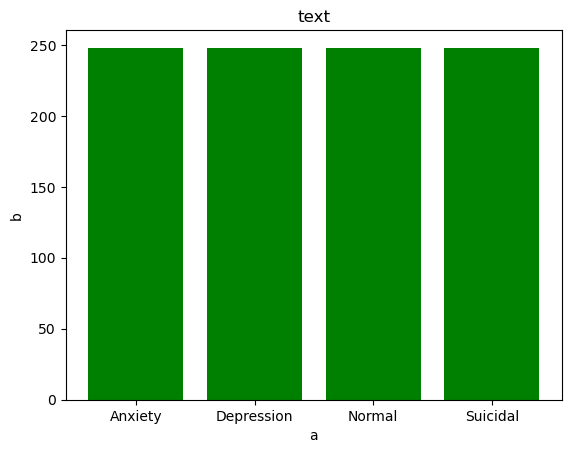

In [8]:
#Visualizations
#Distribution of review types

x=df['status'].value_counts()
m=x.index
n=x.values
plt.bar(m,n,color='g')
plt.title('text')
plt.xlabel('a')
plt.ylabel('b')
plt.show()

In [9]:
df=pd.get_dummies(df,columns=['status'],dtype='int')
df

,text,status_Anxiety,status_Depression,status_Normal,status_Suicidal
0,i don't understand whats wrong with me. i don'...,1,0,0,0
1,usually when i have anxiety just chatting with...,1,0,0,0
2,"well, i've had anxiety and panic syndrome for ...",1,0,0,0
3,"for the most minimal of things, like standing ...",1,0,0,0
4,i stay away from family and live with my roomm...,1,0,0,0
...,...,...,...,...,...
987,Someone jumped off my building todayI wonder w...,0,0,0,1
988,helpp??? took 2800mg ibuprofen &amp; 1800mg as...,0,0,0,1
989,I flunked all my exams am gonna suicideAm goin...,0,0,0,1
990,I've Got A Serious ProblemI am considering tak...,0,0,0,1


In [10]:
#Nlp steps for text column

# Step 1: Lowercase all review text
df['text_lower'] = df['text'].astype(str).str.lower()
df[['text', 'text_lower']].head()

,text,text_lower
0,i don't understand whats wrong with me. i don'...,i don't understand whats wrong with me. i don'...
1,usually when i have anxiety just chatting with...,usually when i have anxiety just chatting with...
2,"well, i've had anxiety and panic syndrome for ...","well, i've had anxiety and panic syndrome for ..."
3,"for the most minimal of things, like standing ...","for the most minimal of things, like standing ..."
4,i stay away from family and live with my roomm...,i stay away from family and live with my roomm...


In [11]:
import re
import string

# Step 2: Remove punctuation and special characters
def remove_punctuation(text):
    return re.sub(f"[{re.escape(string.punctuation)}]", "", text)

df['text_no_punct'] = df['text_lower'].apply(remove_punctuation)
df[['text_lower', 'text_no_punct']].head()


,text_lower,text_no_punct
0,i don't understand whats wrong with me. i don'...,i dont understand whats wrong with me i dont k...
1,usually when i have anxiety just chatting with...,usually when i have anxiety just chatting with...
2,"well, i've had anxiety and panic syndrome for ...",well ive had anxiety and panic syndrome for a ...
3,"for the most minimal of things, like standing ...",for the most minimal of things like standing i...
4,i stay away from family and live with my roomm...,i stay away from family and live with my roomm...


In [12]:
#step 3
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Step 3: Tokenize the cleaned text
df['tokens'] = df['text_no_punct'].apply(word_tokenize)
df[['text_no_punct', 'tokens']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     /home/6c38d984-b659-49f4-a4a2-
[nltk_data]     340a50dc41ed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/6c38d984-b659-49f4-a4a2-
[nltk_data]     340a50dc41ed/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text_no_punct,tokens
0,i dont understand whats wrong with me i dont k...,"[i, dont, understand, whats, wrong, with, me, ..."
1,usually when i have anxiety just chatting with...,"[usually, when, i, have, anxiety, just, chatti..."
2,well ive had anxiety and panic syndrome for a ...,"[well, ive, had, anxiety, and, panic, syndrome..."
3,for the most minimal of things like standing i...,"[for, the, most, minimal, of, things, like, st..."
4,i stay away from family and live with my roomm...,"[i, stay, away, from, family, and, live, with,..."


In [13]:
#step 4
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
#print(stop_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/6c38d984-b659-49f4-a4a2-
[nltk_data]     340a50dc41ed/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Step 4: Remove stopwords from token list
df['tokens_no_stopwords'] = df['tokens'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
df[['tokens', 'tokens_no_stopwords']].head()

,tokens,tokens_no_stopwords
0,"[i, dont, understand, whats, wrong, with, me, ...","[dont, understand, whats, wrong, dont, know, f..."
1,"[usually, when, i, have, anxiety, just, chatti...","[usually, anxiety, chatting, someone, someone,..."
2,"[well, ive, had, anxiety, and, panic, syndrome...","[well, ive, anxiety, panic, syndrome, years, s..."
3,"[for, the, most, minimal, of, things, like, st...","[minimal, things, like, standing, someones, wa..."
4,"[i, stay, away, from, family, and, live, with,...","[stay, away, family, live, roommate, literally..."


In [15]:
#step 5: Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Step 5: Lemmatize each token
df['lemmatized_tokens'] = df['tokens_no_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
df[['tokens_no_stopwords', 'lemmatized_tokens']].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/6c38d984-b659-49f4-a4a2-
[nltk_data]     340a50dc41ed/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/6c38d984-b659-49f4-a4a2-
[nltk_data]     340a50dc41ed/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tokens_no_stopwords,lemmatized_tokens
0,"[dont, understand, whats, wrong, dont, know, f...","[dont, understand, whats, wrong, dont, know, f..."
1,"[usually, anxiety, chatting, someone, someone,...","[usually, anxiety, chatting, someone, someone,..."
2,"[well, ive, anxiety, panic, syndrome, years, s...","[well, ive, anxiety, panic, syndrome, year, st..."
3,"[minimal, things, like, standing, someones, wa...","[minimal, thing, like, standing, someone, way,..."
4,"[stay, away, family, live, roommate, literally...","[stay, away, family, live, roommate, literally..."


In [16]:
# Step 6: Join tokens back into a cleaned string
df['final_cleaned_text'] = df['lemmatized_tokens'].apply(lambda tokens: " ".join(tokens))
df[['text', 'final_cleaned_text']].head()

,text,final_cleaned_text
0,i don't understand whats wrong with me. i don'...,dont understand whats wrong dont know freak so...
1,usually when i have anxiety just chatting with...,usually anxiety chatting someone someone physi...
2,"well, i've had anxiety and panic syndrome for ...",well ive anxiety panic syndrome year started s...
3,"for the most minimal of things, like standing ...",minimal thing like standing someone way moment...
4,i stay away from family and live with my roomm...,stay away family live roommate literally game ...


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

x = vectorizer.fit_transform(df['final_cleaned_text'])

# dummy encoded labels
y = df.filter(like='status_').idxmax(axis=1)

In [31]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(793, 5000)
(199, 5000)
(793,)
(199,)


In [33]:
#Model selection or model building

# 1.import algorithm
from sklearn.linear_model import LogisticRegression
# 2.object for class
# model 
lr_=LogisticRegression()

In [34]:
#Model training
lr_.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
#Model testing---x_text data
result=lr_.predict(x_test)
print(result)

['status_Anxiety' 'status_Depression' 'status_Depression'
 'status_Depression' 'status_Depression' 'status_Normal'
 'status_Depression' 'status_Anxiety' 'status_Anxiety' 'status_Normal'
 'status_Depression' 'status_Anxiety' 'status_Depression'
 'status_Suicidal' 'status_Anxiety' 'status_Suicidal' 'status_Depression'
 'status_Normal' 'status_Anxiety' 'status_Suicidal' 'status_Anxiety'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Depression' 'status_Suicidal' 'status_Normal' 'status_Depression'
 'status_Normal' 'status_Suicidal' 'status_Depression' 'status_Normal'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Suicidal'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Depression'
 'status_Anxiety' 'status_Anxiety' 'status_Normal' 'status_Anxiety'
 'status_Anxiety' 'status_Normal' 'status_Depression' 'status_Normal'
 'status_Normal' 'status_Anxiety' 'status_Depression' 'status_Suicidal'
 'status_Normal' 'status_Suicidal' 'status_Suicidal' 'st

In [37]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score=accuracy_score(y_test,result)
print("Accuracy Score for LR Model:",score)

Accuracy Score for LR Model: 0.6432160804020101


In [38]:
#classification report
report=classification_report(y_test,result)
print("Classification Report :\n")
print(report)

Classification Report :

                   precision    recall  f1-score   support

   status_Anxiety       0.76      0.70      0.73        44
status_Depression       0.54      0.45      0.49        49
    status_Normal       0.67      0.84      0.75        51
  status_Suicidal       0.60      0.58      0.59        55

         accuracy                           0.64       199
        macro avg       0.64      0.64      0.64       199
     weighted avg       0.64      0.64      0.64       199



[[31  4  4  5]
 [ 5 22  8 14]
 [ 3  3 43  2]
 [ 2 12  9 32]]


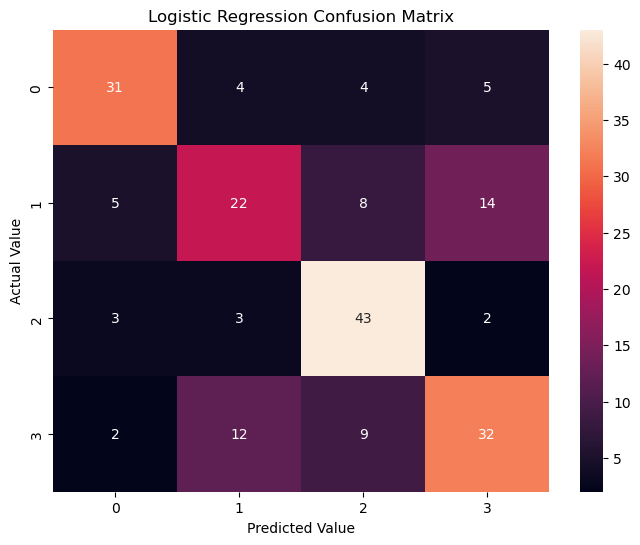

In [39]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,result)
print(cm)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Logistic Regression Confusion Matrix")

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [40]:
# Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier
# model building
dt=DecisionTreeClassifier()
#Model training
dt.fit(x_train,y_train)

#Model testing---x_text data

result_dt=dt.predict(x_test)
print(result_dt)

['status_Anxiety' 'status_Normal' 'status_Suicidal' 'status_Normal'
 'status_Depression' 'status_Normal' 'status_Depression' 'status_Anxiety'
 'status_Anxiety' 'status_Suicidal' 'status_Depression' 'status_Suicidal'
 'status_Depression' 'status_Anxiety' 'status_Normal' 'status_Suicidal'
 'status_Depression' 'status_Normal' 'status_Anxiety' 'status_Suicidal'
 'status_Anxiety' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Depression' 'status_Suicidal' 'status_Anxiety' 'status_Suicidal'
 'status_Depression' 'status_Depression' 'status_Depression'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Suicidal' 'status_Suicidal' 'status_Normal' 'status_Suicidal'
 'status_Suicidal' 'status_Suicidal' 'status_Depression' 'status_Anxiety'
 'status_Normal' 'status_Normal' 'status_Depression' 'status_Anxiety'
 'status_Depression' 'status_Suicidal' 'status_Anxiety' 'status_Normal'
 'status_Suicidal' 'status_Normal' 'status_Normal' 'status_Depression'
 'status_Depress

Accuracy Score for DT Model: 0.5226130653266332
Classification Report :

                   precision    recall  f1-score   support

   status_Anxiety       0.67      0.64      0.65        44
status_Depression       0.43      0.47      0.45        49
    status_Normal       0.56      0.53      0.55        51
  status_Suicidal       0.47      0.47      0.47        55

         accuracy                           0.52       199
        macro avg       0.53      0.53      0.53       199
     weighted avg       0.53      0.52      0.52       199

[[28  9  4  3]
 [ 4 23  8 14]
 [ 7  5 27 12]
 [ 3 17  9 26]]


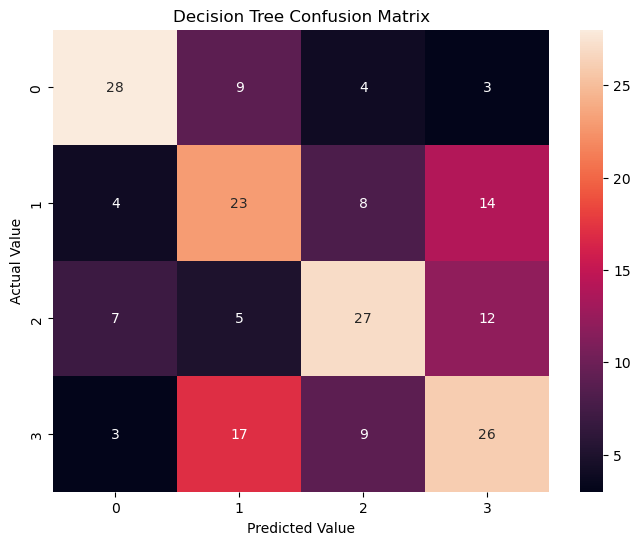

In [41]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_dt=accuracy_score(y_test,result_dt)
print("Accuracy Score for DT Model:",score_dt)

#classification report
report_dt=classification_report(y_test,result_dt)
print("Classification Report :\n")
print(report_dt)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt=confusion_matrix(y_test,result_dt)
print(cm_dt)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree Confusion Matrix")

sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [42]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

# model building
rf=RandomForestClassifier()
#Model training
rf.fit(x_train,y_train)
#Model testing---x_text data
result_rf=rf.predict(x_test)
print(result_rf)

['status_Anxiety' 'status_Normal' 'status_Depression' 'status_Normal'
 'status_Depression' 'status_Normal' 'status_Normal' 'status_Anxiety'
 'status_Anxiety' 'status_Normal' 'status_Depression' 'status_Anxiety'
 'status_Depression' 'status_Anxiety' 'status_Normal' 'status_Suicidal'
 'status_Suicidal' 'status_Normal' 'status_Depression' 'status_Suicidal'
 'status_Anxiety' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Normal' 'status_Suicidal' 'status_Anxiety' 'status_Normal'
 'status_Depression' 'status_Normal' 'status_Depression' 'status_Normal'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Suicidal' 'status_Normal' 'status_Normal' 'status_Depression'
 'status_Depression' 'status_Anxiety' 'status_Anxiety' 'status_Normal'
 'status_Normal' 'status_Depression' 'status_Normal' 'status_Suicidal'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Depression'
 'status_Suicidal' 'status_Normal' 'status_Suicidal' 'status_Depression'
 'status_Normal' 

Accuracy Score for RF Model: 0.6130653266331658
Classification Report :

                   precision    recall  f1-score   support

   status_Anxiety       0.67      0.70      0.69        44
status_Depression       0.54      0.43      0.48        49
    status_Normal       0.60      0.80      0.69        51
  status_Suicidal       0.63      0.53      0.57        55

         accuracy                           0.61       199
        macro avg       0.61      0.62      0.61       199
     weighted avg       0.61      0.61      0.61       199

[[31  6  5  2]
 [ 5 21 11 12]
 [ 5  2 41  3]
 [ 5 10 11 29]]


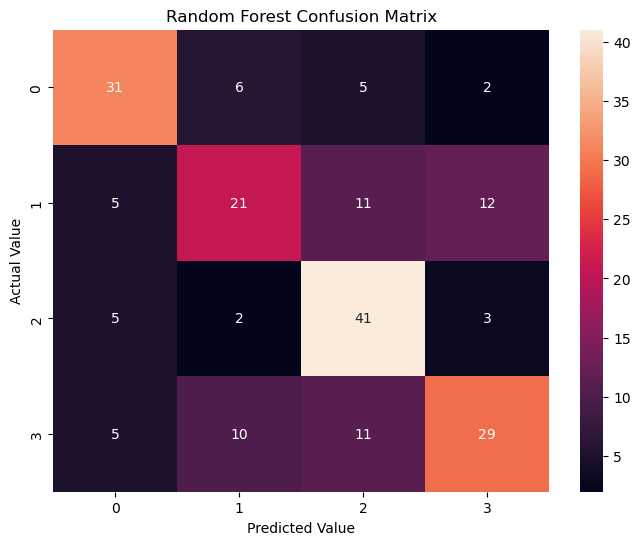

In [43]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_rf=accuracy_score(y_test,result_rf)
print("Accuracy Score for RF Model:",score_rf)

#classification report
report_rf=classification_report(y_test,result_rf)
print("Classification Report :\n")
print(report_rf)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf=confusion_matrix(y_test,result_rf)
print(cm_rf)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Random Forest Confusion Matrix")

sns.heatmap(cm_rf,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [44]:
#Support Vector machine
from sklearn.svm import SVC
# model building
svc=SVC()
#Model training
svc.fit(x_train,y_train)
#Model testing---x_text data
result_svc=svc.predict(x_test)
print(result_svc)

['status_Anxiety' 'status_Depression' 'status_Depression'
 'status_Depression' 'status_Depression' 'status_Normal'
 'status_Depression' 'status_Anxiety' 'status_Anxiety' 'status_Normal'
 'status_Depression' 'status_Anxiety' 'status_Depression'
 'status_Suicidal' 'status_Depression' 'status_Suicidal'
 'status_Depression' 'status_Normal' 'status_Anxiety' 'status_Suicidal'
 'status_Anxiety' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Normal' 'status_Depression' 'status_Suicidal' 'status_Normal'
 'status_Depression' 'status_Normal' 'status_Suicidal' 'status_Normal'
 'status_Normal' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Suicidal' 'status_Normal' 'status_Normal' 'status_Normal'
 'status_Depression' 'status_Anxiety' 'status_Anxiety' 'status_Normal'
 'status_Anxiety' 'status_Anxiety' 'status_Normal' 'status_Depression'
 'status_Normal' 'status_Normal' 'status_Anxiety' 'status_Depression'
 'status_Suicidal' 'status_Normal' 'status_Suicidal' 'status_Suicidal'
 'st

Accuracy Score for svc Model: 0.6482412060301508
Classification Report :

                   precision    recall  f1-score   support

   status_Anxiety       0.82      0.70      0.76        44
status_Depression       0.53      0.49      0.51        49
    status_Normal       0.67      0.86      0.75        51
  status_Suicidal       0.60      0.55      0.57        55

         accuracy                           0.65       199
        macro avg       0.65      0.65      0.65       199
     weighted avg       0.65      0.65      0.64       199

[[31  5  4  4]
 [ 3 24  8 14]
 [ 3  2 44  2]
 [ 1 14 10 30]]


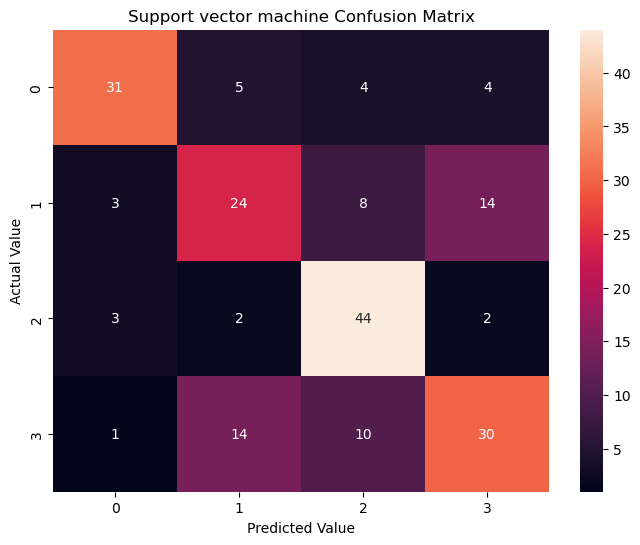

In [46]:
#model evaluation

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_svc=accuracy_score(y_test,result_svc)
print("Accuracy Score for svc Model:",score_svc)

#classification report
report_svc=classification_report(y_test,result_svc)
print("Classification Report :\n")
print(report_svc)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svc=confusion_matrix(y_test,result_svc)
print(cm_svc)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Support vector machine Confusion Matrix")

sns.heatmap(cm_svc,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [48]:
import joblib

# Save SVM model
joblib.dump(svc, 'svm1_model_nlp.pkl')

# Save TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf1_vectorizer.pkl')

['tfidf1_vectorizer.pkl']

In [64]:
import joblib
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load saved model and vectorizer
svm_model = joblib.load('svm_model_nlp.pkl')
tfidf_vectorizer = joblib.load('tfidf_vectorizer.pkl')


def predict_mental_health(text):
    
    # Step 1: Lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Step 5: Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Step 6: Join tokens
    clean_text = " ".join(tokens)
    
    # Step 7: Vectorize
    X_input = tfidf_vectorizer.transform([clean_text])
    
    # Step 8: Predict
    prediction = svm_model.predict(X_input)[0]
    
    # Step 9: Convert to label (if LabelEncoder used)
    try:
        prediction_label = label_encoder.inverse_transform([prediction])[0]
    except:
        prediction_label = prediction   # if already string labels
    
    print("Predicted Mental Health:", prediction_label)
    
    return prediction_label

In [65]:
predict_mental_health("I feel very stressed and anxious all the time")

Predicted Mental Health: status_Anxiety


'status_Anxiety'

In [66]:
predict_mental_health("I feel very tired")

Predicted Mental Health: status_Depression


'status_Depression'

In [67]:
user_text = str(input("Enter your text: "))

result = predict_mental_health(user_text)

print("Prediction:", result)

Enter your text:  I am sad


Predicted Mental Health: status_Normal
Prediction: status_Normal
